         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

/tmp/ipykernel_5385/1727793392.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


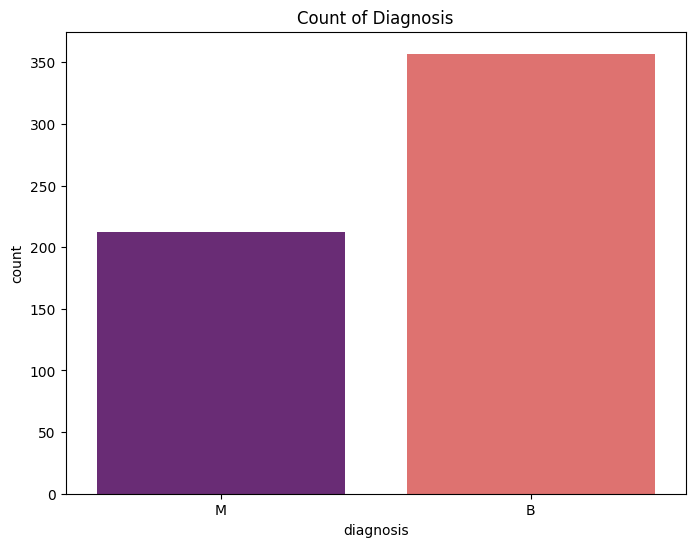

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Examine the first few rows
print(df.head())

# Check and handle missing values
# 'Unnamed: 32' is entirely null, and 'id' is not useful for prediction
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

# Create a Countplot to display diagnosis from magma
plt.figure(figsize=(8,6))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Count of Diagnosis')
plt.show()


In [2]:
# Counts of unique rows in the ‘diagnosis’ column
print("Diagnosis counts:\n", df['diagnosis'].value_counts())

# Map categorical values to numerical values
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Splitting the data into features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Splitting into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Diagnosis counts:
 diagnosis
B    357
M    212
Name: count, dtype: int64


In [3]:
# 1. Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_scaled))
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# 2. K Nearest Neighbours
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
knn_acc = accuracy_score(y_test, knn_model.predict(X_test_scaled))
print(f"K Nearest Neighbours Accuracy: {knn_acc:.4f}")

# 3. Random Forests
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))
print(f"Random Forests Accuracy: {rf_acc:.4f}")

# 4. Support Vector Machines (SVM)
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
svm_acc = accuracy_score(y_test, svm_model.predict(X_test_scaled))
print(f"SVM Accuracy: {svm_acc:.4f}")

Logistic Regression Accuracy: 0.9737
K Nearest Neighbours Accuracy: 0.9474
Random Forests Accuracy: 0.9649
SVM Accuracy: 0.9825
